<a href="https://colab.research.google.com/github/sanaullah-developer/tensorflow_practice/blob/main/Cat_and_Dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import os
import shutil
import random
import tensorflow as tf
from PIL import Image
from tensorflow.keras import layers, models


In [20]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("marquis03/cats-and-dogs")
print("Dataset path:", path)

# Assume dataset has `train/Cat` and `train/Dog` folders
CAT_DIR = os.path.join(path, "train", "Cat")
DOG_DIR = os.path.join(path, "train", "Dog")


100%|██████████| 9.75M/9.75M [00:00<00:00, 198MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/marquis03/cats-and-dogs/versions/2


In [22]:
print(os.listdir(path))

['train', 'train.csv', 'val', 'val.csv']


In [23]:
for root, dirs, files in os.walk(path):
    print(root, "->", dirs[:5], len(files))


/root/.cache/kagglehub/datasets/marquis03/cats-and-dogs/versions/2 -> ['train', 'val'] 2
/root/.cache/kagglehub/datasets/marquis03/cats-and-dogs/versions/2/train -> ['cat', 'dog'] 1
/root/.cache/kagglehub/datasets/marquis03/cats-and-dogs/versions/2/train/cat -> [] 95
/root/.cache/kagglehub/datasets/marquis03/cats-and-dogs/versions/2/train/dog -> [] 180
/root/.cache/kagglehub/datasets/marquis03/cats-and-dogs/versions/2/val -> ['cat', 'dog'] 1
/root/.cache/kagglehub/datasets/marquis03/cats-and-dogs/versions/2/val/cat -> [] 24
/root/.cache/kagglehub/datasets/marquis03/cats-and-dogs/versions/2/val/dog -> [] 46


In [24]:
import tensorflow as tf
import os

BASE = "/root/.cache/kagglehub/datasets/marquis03/cats-and-dogs/versions/2"

def purge_invalid(folder):
    for cls in ["cat", "dog"]:
        path_cls = os.path.join(folder, cls)
        for f in os.listdir(path_cls):
            fp = os.path.join(path_cls, f)
            try:
                raw = tf.io.read_file(fp)
                _ = tf.image.decode_jpeg(raw, channels=3)
            except:
                os.remove(fp)
                print("Removed invalid file:", fp)

purge_invalid(os.path.join(BASE,"train"))
purge_invalid(os.path.join(BASE,"val"))


In [25]:
IMG_SIZE = (224,224)
BATCH = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE,"train"),
    image_size=IMG_SIZE,
    batch_size=BATCH
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE,"val"),
    image_size=IMG_SIZE,
    batch_size=BATCH
)


Found 275 files belonging to 2 classes.
Found 70 files belonging to 2 classes.


In [26]:


normalization = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x,y: (normalization(x), y)).cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.map(lambda x,y: (normalization(x), y)).cache().prefetch(tf.data.AUTOTUNE)


In [27]:
IMG_SIZE = (224,224)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # freeze backbone


In [28]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")  # binary classification
])


In [29]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [30]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    verbose=1,
    epochs=10
)


Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8871 - loss: 0.3141 - val_accuracy: 0.9714 - val_loss: 0.1552
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9965 - loss: 0.0127 - val_accuracy: 1.0000 - val_loss: 0.0796
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 0.0531
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 1.0000 - loss: 7.0478e-04 - val_accuracy: 1.0000 - val_loss: 0.0391
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 1.0000 - loss: 7.6628e-04 - val_accuracy: 1.0000 - val_loss: 0.0300
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 1.0000 - loss: 7.3232e-04 - val_accuracy: 1.0000 - val_loss: 0.0234
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 1.0000 - loss: 6.5524e-04 - val_accuracy: 1.0000 - val_loss: 0.0179
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 1.0000 - loss: 9.9929e-04 - val_accuracy: 1.0000 - val_l

In [31]:
model.evaluate(val_ds)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 581ms/step - accuracy: 1.0000 - loss: 0.0087


[0.008834672160446644, 1.0]

In [32]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),       # horizontal flip
    layers.RandomRotation(0.1),           # ±10% rotation
    layers.RandomZoom(0.1),               # ±10% zoom
    layers.RandomContrast(0.1),           # ±10% contrast
])


In [33]:
IMG_SIZE = (224,224)
BATCH = 32

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)


In [34]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [35]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.6667 - loss: 0.6139 - val_accuracy: 0.9714 - val_loss: 0.1391
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9984 - loss: 0.0321 - val_accuracy: 0.9857 - val_loss: 0.0615
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 1.0000 - loss: 0.0067 - val_accuracy: 0.9857 - val_loss: 0.0435
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 1.0000 - val_loss: 0.0340
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 0.0272
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 0.0216
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 1.0000 - loss: 9.2905e-04 - val_accuracy: 1.0000 - val_loss: 0.0168
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 0.0135
Epoc

In [36]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.9572 - loss: 0.0619 - val_accuracy: 1.0000 - val_loss: 0.0067
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 1.0000 - loss: 0.0082 - val_accuracy: 1.0000 - val_loss: 0.0040
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 0.0028
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 1.0000 - loss: 6.0738e-04 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 1.0000 - loss: 4.0851e-04 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 1.0000 - loss: 3.6566e-04 - val_accuracy: 1.0000 - val_loss: 0.0

In [37]:
model.evaluate(val_ds)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 728ms/step - accuracy: 1.0000 - loss: 0.0014


[0.0014313914580270648, 1.0]

In [38]:
test_ds = val_ds  # rename for clarity


In [39]:
loss, acc = model.evaluate(test_ds)
print(f"Test Accuracy: {acc*100:.2f}%, Test Loss: {loss:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 588ms/step - accuracy: 1.0000 - loss: 0.0014
Test Accuracy: 100.00%, Test Loss: 0.0014


In [40]:
import numpy as np

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_prob = np.concatenate([model.predict(x) for x, y in test_ds], axis=0)
y_pred = (y_pred_prob > 0.5).astype(int)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


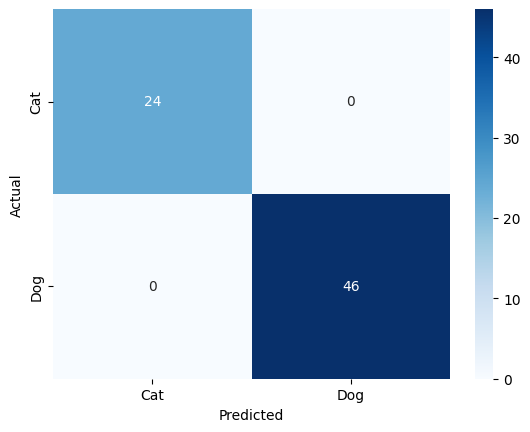

In [41]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cat','Dog'], yticklabels=['Cat','Dog'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [42]:
print(classification_report(y_true, y_pred, target_names=['Cat','Dog']))


              precision    recall  f1-score   support

         Cat       1.00      1.00      1.00        24
         Dog       1.00      1.00      1.00        46

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70

